In [9]:
import sys, os, json
sys.path.append(os.path.abspath("./../../feedback-grape"))
sys.path.append(os.path.abspath("./../../"))
sys.path.append(os.path.abspath("./../"))

from matplotlib import pyplot as plt
import numpy as np

from plot_helpers import * # to apply consistent plotting style

In [10]:
max_timesteps = 11

dir_ = "./eval/"

lut_bb001 = json.load(open(dir_ + "lut_model=lut_t=3_l=2_w=001_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0.json"))["fidelity_each_timestep"][:max_timesteps]
lut_bb011 = json.load(open(dir_ + "lut_model=lut_t=3_l=2_w=011_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0.json"))["fidelity_each_timestep"][:max_timesteps]
lut_bb111 = json.load(open(dir_ + "lut_model=lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0.json"))["fidelity_each_timestep"][:max_timesteps]

rnn_bb001 = json.load(open(dir_ + "rnn_model=rnn_t=3_w=001_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0.json"))["fidelity_each_timestep"][:max_timesteps]
rnn_bb011 = json.load(open(dir_ + "rnn_model=rnn_t=3_w=011_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0.json"))["fidelity_each_timestep"][:max_timesteps]
rnn_bb111 = json.load(open(dir_ + "rnn_model=rnn_t=3_w=111_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0.json"))["fidelity_each_timestep"][:max_timesteps]

lut_l6 = json.load(open(dir_ + "lut_model=lut_t=3_l=6_w=111_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0.json"))["fidelity_each_timestep"][:max_timesteps]

baseline_b = np.load("./baseline/lut_model=lut_t=3_l=2_w=001_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=0..npz")["fidelities"][:max_timesteps]

Final fidelities: [32.50960651 12.89129782 69.37776755 12.51403974 66.2816199  33.74592334
 16.80278704 34.22829131]
3rd timestep: [89.01202895 91.85872731 87.5259238  78.61818437 85.8562563  71.21274573
 88.29145512 69.60013538]


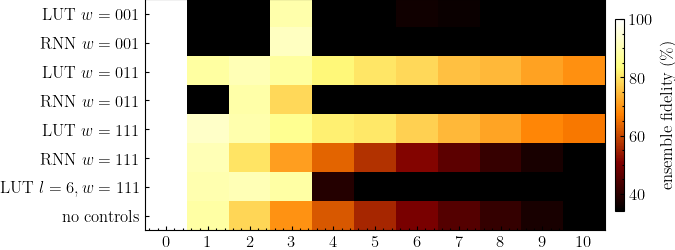

In [11]:
fig, ax1 = plt.subplots(1,1, figsize=(6.1811,3))
mat1 = np.array([lut_bb001, rnn_bb001, lut_bb011, rnn_bb011, lut_bb111, rnn_bb111, lut_l6, baseline_b])*100
print("Final fidelities:", mat1[:,-1])
print("3rd timestep:", mat1[:,3])
im = ax1.imshow(
    mat1,
    aspect='auto',
    extent=[-0.5, max_timesteps-0.5, 0, 8],
    origin='upper',
    cmap='afmhot',
    vmin=baseline_b[-1]*100,
    vmax=100
)
cbar = fig.colorbar(im, ax=ax1, orientation='vertical', fraction=0.02, pad=0.02, label='$\\textrm{ensemble fidelity }(\\%)$')

ax1.set_yticks(
    [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5][::-1],
    [
        "$\\textrm{LUT }w=001$",
        "$\\textrm{RNN }w=001$",
        "$\\textrm{LUT }w=011$",
        "$\\textrm{RNN }w=011$",
        "$\\textrm{LUT }w=111$",
        "$\\textrm{RNN }w=111$",
        "$\\textrm{LUT }l=6,w=111$",
        "$\\textrm{no controls}$",
    ]
)
ax1.yaxis.minorticks_off()
ax1.set_xticks(np.arange(0, max_timesteps, 1))

fig.savefig("./comparison_training_parameters.svg", bbox_inches='tight')